In [24]:
import numpy as np
import matplotlib.pyplot as plt
from fractions import Fraction
from math import gcd, ceil, log2, pi
import time

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.circuit.library import QFT

import warnings
warnings.filterwarnings('ignore')

## **CLASSICAL HELPER FUNCTION**

In [25]:
def is_prime(N):
    #cek N salah satunya prima
    if N < 2: return False
    for i in range(2, int(n**0.5)+1):
        if N % i == 0: return False
    return True

def is_semiprime(N):
    #cek N keduanya prima
    for i in range(2, int(n**0.5)+1):
        if n % i == 0 and is_prime(i) and is_prime(N//i):
            return False
        return False

def mod_exp_classical(a, power, N):
    #classical modular a^power mod N
    return pow(int(a), int(power), int(N))

def find_period_classical(a, N):
    #classic menemukan periode r dari a^r ≡ 1 (mod N)
    r = 1
    val = a % N
    while val != 1:
        val = (val * a) % N
        r += 1
        if r > N:
            return None
    return r

def get_factors_from_period(a, r, N):
    #ekstrak faktor N dengan periode r dan a
    if r is None or r % 2 != 0:
        return None, None
    x = pow(int(a), r//2, N)
    if x == N - 1:
        return None, None
    f1 =  gcd(x + 1, N)
    f2 = gcd(x - 1, N)
    if f1 not in [1, N] and f2 not in [1, N]:
        return f1, f2
    return None, None

def continued_fraction_period(measured, t, N):
    #untuk mengektrak periode r dari perhitungan
    if measured == 0:
        return None
    frac = Fraction(measure, 2**t).limit_denominator(N)
    return frac.denominator

## **MEMBANGUN QUANTUM CIRCUIT**

### ***1. EXACT QFT***

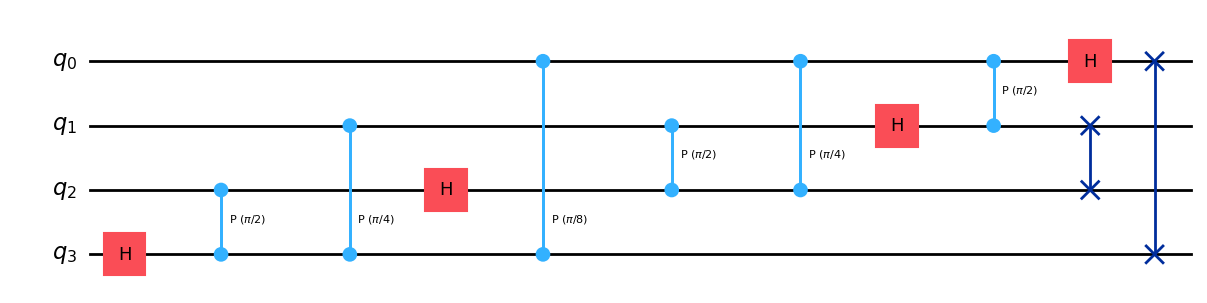

In [26]:
def build_exact_qft(n_qubits, inverse=False):
    #Build exact QFT circuit on n_qubits. O(n^2) gates
    qc = QuantumCircuit(n_qubits, name= 'QFT' if not inverse else 'IQFT')

    if not inverse:
        for i in range(n_qubits -1, -1, -1):
            qc.h(i)
            for j in range(i -1, -1, -1):
                angle = np.pi/(2**(i-j))
                qc.cp(angle, j, i)
        
        #swap qubits
        for i in range(n_qubits//2):
            qc.swap(i, n_qubits - 1 -i)
    
    else:
        #inverse QFT
        for i in range (n_qubits//2):
            qc.swap(i, n_qubits - 1 -i)
        for i in range(n_qubits):
            for j in range(i - 1, -1, -1):
                angle = np.pi/ (2 ** (i-j))
                qc.cp(angle, j, i)
            qc.h(i)
    return qc

build_exact_qft(4).draw('mpl')


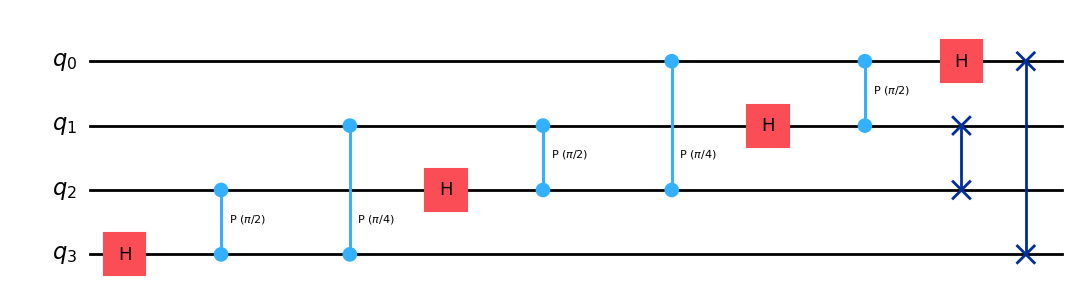

In [27]:
def build_approx_qft(n_qubits, kmax=None, inverse=False):
    #Build approximate QFT circuit. 
    #Reduces gates from O(n^2) to O(n log n).
    #Prunes controlled-phase gates where rotation>kmax threshold
    if kmax is None:
        kmax = int(np.log2(n_qubits)) if n_qubits > 1 else 1

    qc = QuantumCircuit(n_qubits, name=f'AQFT(k={kmax})' if not inverse else f'AQFT†(k={kmax})')

    if not inverse:
        #listing 1
        i = n_qubits - 1
        while i >= 0:
            qc.h(i)
            j = i - 1
            while j >= 0 and (i - j) <= kmax:
                angle = np.pi / (2**(i - j))
                if angle > 0:
                    qc.cp(angle, j, i)
                j -= 1
            i -= 1
        #swap
        for i in range(n_qubits // 2):
            qc.swap(i, n_qubits - 1 - i)
    
    else:
        #inverse approximate QFT
        for i in range(n_qubits // 2):
            qc.swap(i, n_qubits - 1 - i)
        i = 0
        while i < n_qubits:
            j = i - 1
            while j >= 0 and (i - j) <= kmax:
                angle = -np.pi / (2**(i - j))
                if angle != 0:
                    qc.cp(angle, j, i)
                j -= 1
            qc.h(i)
            i += 1
    
    return qc

build_approx_qft(4, kmax=2).draw('mpl')

### ***2. QFT BASED ADDER (DRAPPER ADDER)***

adds classical integer a to quantum register. Assumes register os a;ready in QFT basis. Based on Draper's addition on a quantum computer.

In [37]:
def qft_add(n, a, use_approx=False, kmax=None):
    qc = QuantumCircuit(n, name=f'Add({a})')

    if kmax is None:
        kmax = n if not use_approx else int(np.log2(n)) if n > 1 else 1

    for i in range(n):
        for j in range(i + 1):
            if (i - j) < kmax or not use_approx:
                #phase contribution of bit j of a to qubit i
                if (a >> j) & i:
                    angle = 2 * np.pi / (2** (i - j + 1))
                    qc.p(angle, i)
    return qc 

#qft_add(4, 5, kmax=2).draw('mpl')

In [38]:
def qft_add_mod_N(n, a, N, use_approx=False):
    #modular QFT adder is for compute (x + a) mod N in QFT basis.
    #Simplified version using ancilla-free approach
    qc = QuantumCircuit(n + 1, name=f'AddMod({a}, {N})')

    #This is a simplified placeholder for the full Beauregard circuit
    #Full implementation would include overflow detection
    for i in range(n):
        for j in range(i + 1):
            if (a >> j) & 1:
                angle = 2 * np.pi / (2 ** (i - j +1))
                qc.p(angle, i)
    return qc

### ***3. CONTROLLED MODULAR EXPONENTIATION (simplified)***

In [39]:
def buils_ctrl_U(a, power, N, n_qubits):
    #Build the unitary U^(2^power) which maps |y> -> |a^(2^power) * y mod N>.
    #This is the controlled modular multiplication gate.
    #Uses matrix representation for small N (simulation purposes)

    dim = 2 ** n_qubits
    U = np.zeros((dim, dim), dtype=complex)

    a_pow = pow(int(a), int(2**power), int(N))

    for y in range(dim):
        if y < N:
            new_y = (a_pow * y) % N
            U[new_y][y] = 1
        else:
            U[y][y] = 1         #identity for states >= N

    gate = QuantumCircuit(n_qubits, name=f'U^{2**power}')
    gate.unitary(U, range(n_qubits))
    return gate.to_gate().control(1)